In [13]:
import numpy as np
import torch
from dataloaders import GetSingleStepDataLoaders
data  = np.load('/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/data/test_comb_med_neg.npz')
states = data['coords_t']
states_tp1 = data['coords_tp1']
steps = data['steps']
positions = data['positions']
rotations = data['rotations']
actions = np.hstack((steps, positions, rotations))

point_size = states.shape[1]
latent_size = 256
batch_size = 32
output_folder = "./output_cogging/"
save_results = True
use_GPU = True
epochs = 201
max_rollout_horizon = 10


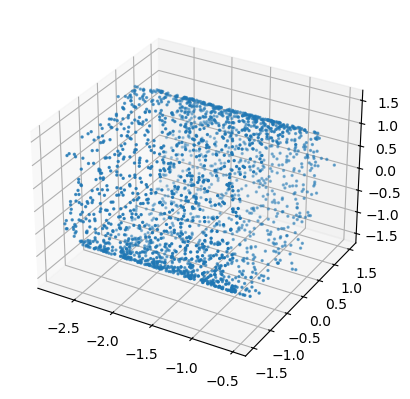

In [ ]:
import torch
import model

net = model.PCTransitionModel(point_size, latent_size)
net.load_state_dict(torch.load("transition_model_comb_neg_2G.pth", weights_only=True))
net.eval()
x = torch.tensor(states[2], dtype=torch.float32).T.unsqueeze(0) # x.shape = 1,3,n_points
a = torch.tensor(actions[2], dtype=torch.float32).unsqueeze(0) #a.shape = 1,8
x_np = x.T.squeeze(0).numpy()

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.scatter(xs=x_np[:,0],ys=x_np[:,1],zs=x_np[:,2], s=2)
plt.show()



In [11]:

def forward(x,a):
    with torch.no_grad():
        return(net(x_t=x,a_t=a))

t = 10
for _ in range(t):

    delta = forward(x,a)
    x = x.squeeze(0).T + delta.squeeze(0)
    x = x.T.unsqueeze(0)

x_np = x.T.squeeze(0).numpy()


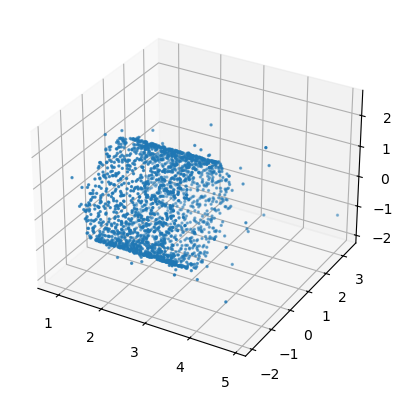

In [12]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.scatter(xs=x_np[:,0],ys=x_np[:,1],zs=x_np[:,2], s=2)
plt.show()